<a href="https://colab.research.google.com/github/varshabantu/Data-Science-Tasks/blob/main/LinearReg_Trip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [3]:
#To check all the datasets
# dir(datasets)

In [4]:
# dir(datasets)
# data preparation
data = fetch_california_housing()
# print(data.DESCR) to know the description
# input columns:
df = pd.DataFrame(data.data,columns=data.feature_names)
# output column :
# data.target
# data.target_names --> list
# data.target_names[0] #--> str
df[data.target_names[0]] = data.target
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


**EDA**

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


<Axes: xlabel='HouseAge', ylabel='Count'>

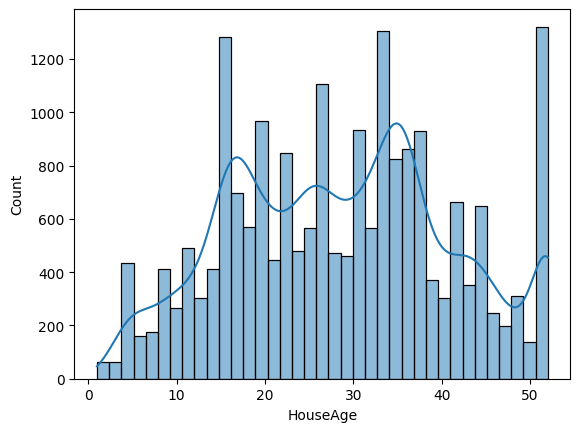

In [7]:
sns.histplot(df["HouseAge"],kde=True)

<Axes: xlabel='HouseAge', ylabel='Count'>

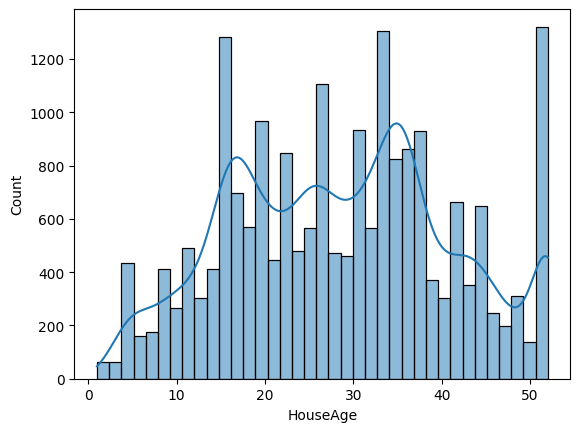

In [8]:
sns.histplot(x="HouseAge",data=df,kde=True)

<Axes: >

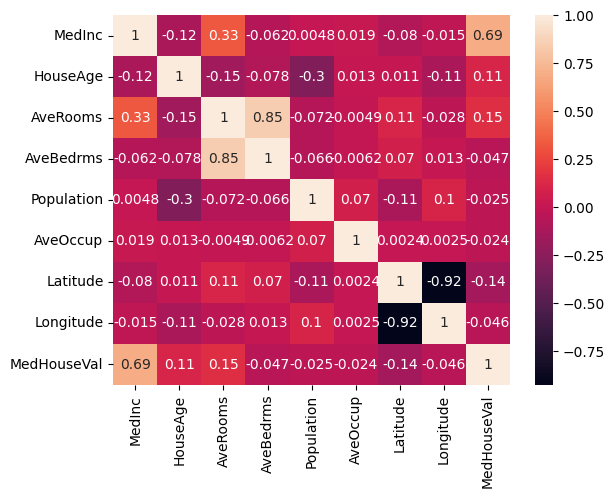

In [9]:
data = df.corr()
sns.heatmap(data,annot=True)

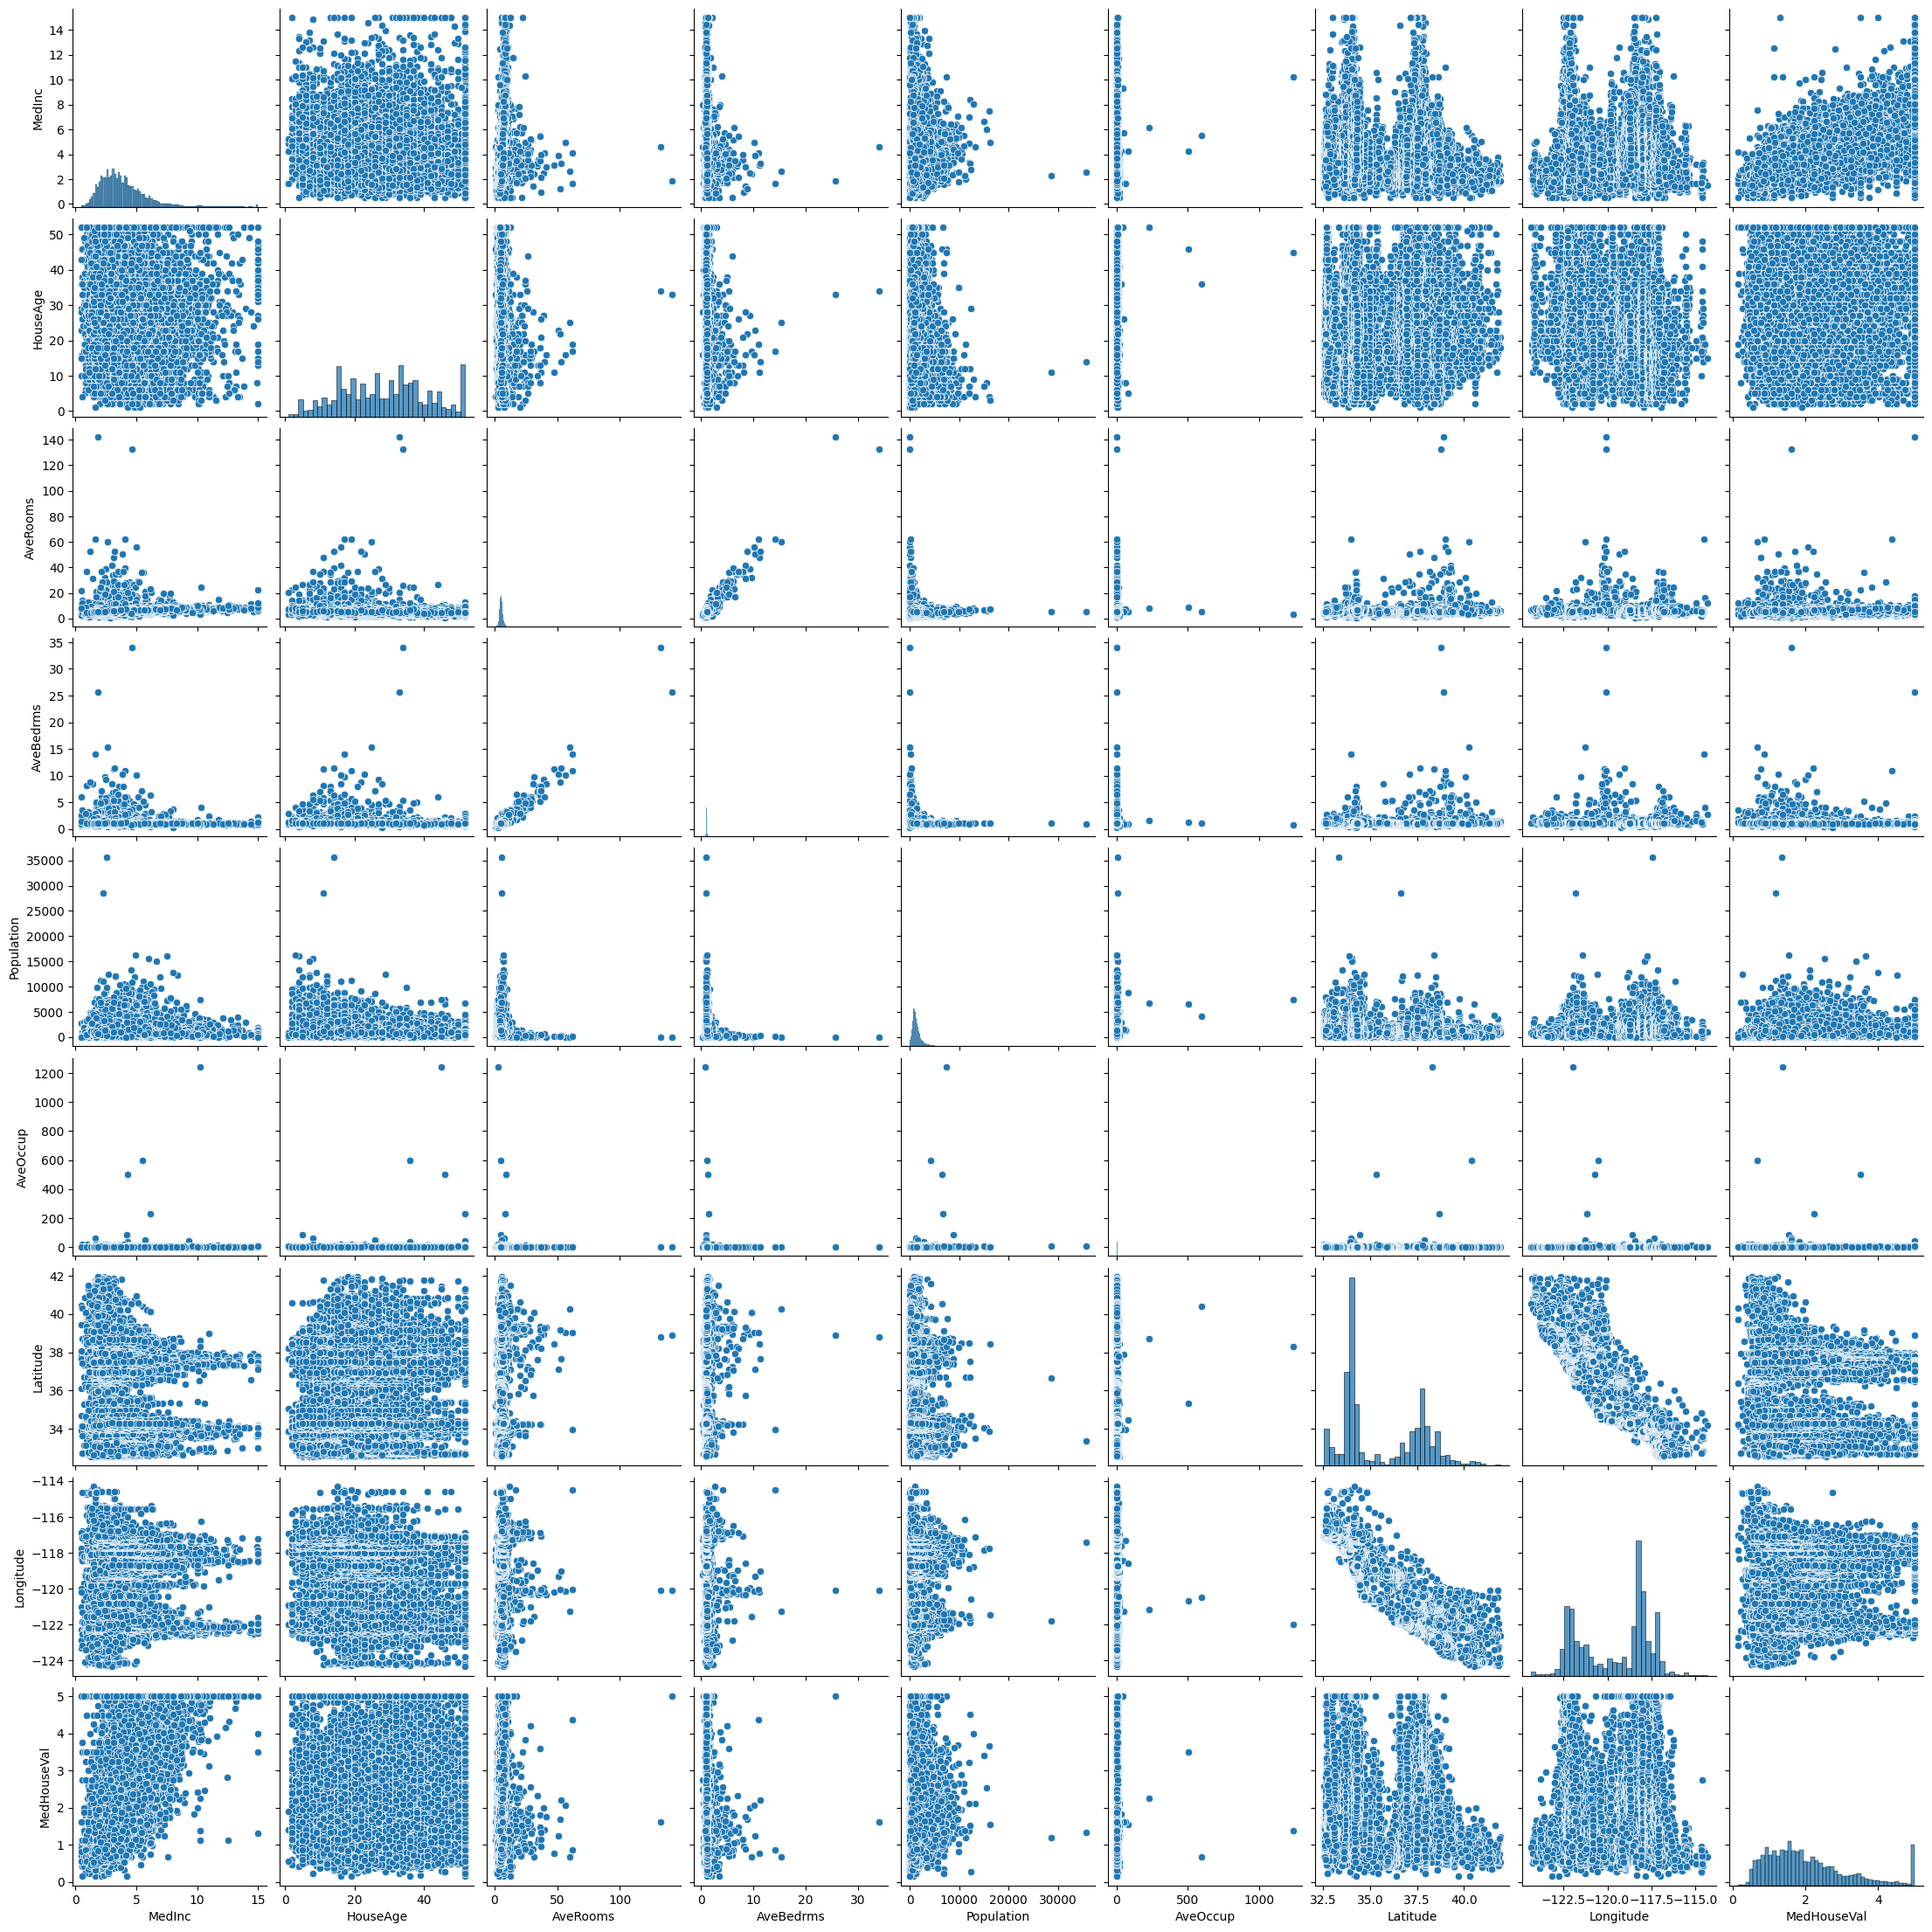

In [10]:
sns.pairplot(df)

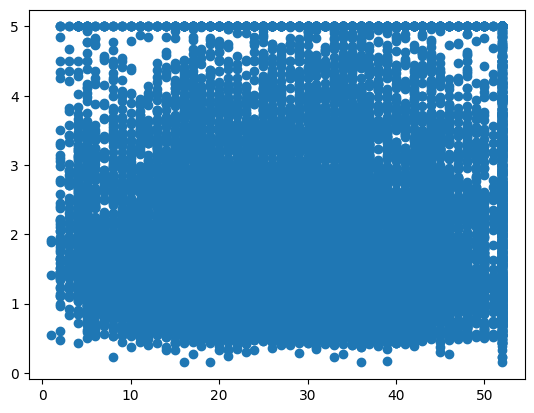

In [11]:
#Checking the correlation btw column
plt.scatter(df["HouseAge"],df["MedHouseVal"])

# Model Training

* To train the model we have 3 steps

In [12]:
# Divide the data into input and output
X = df.drop("MedHouseVal",axis=1)
y = df["MedHouseVal"]

In [13]:
# As per ML rule when we have 100% of data 70% is used for training and 30% is used for testing
# ML rules  ---> 100% ---> 70%(training), 30%(testing)
#Split data into training and testing data

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)
Xtrain

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
7061,4.1312,35.0,5.882353,0.975490,1218.0,2.985294,33.93,-118.02
14689,2.8631,20.0,4.401210,1.076613,999.0,2.014113,32.79,-117.09
17323,4.2026,24.0,5.617544,0.989474,731.0,2.564912,34.59,-120.14
10056,3.1094,14.0,5.869565,1.094203,302.0,2.188406,39.26,-121.00
15750,3.3068,52.0,4.801205,1.066265,1526.0,2.298193,37.77,-122.45
...,...,...,...,...,...,...,...,...
11284,6.3700,35.0,6.129032,0.926267,658.0,3.032258,33.78,-117.96
11964,3.0500,33.0,6.868597,1.269488,1753.0,3.904232,34.02,-117.43
5390,2.9344,36.0,3.986717,1.079696,1756.0,3.332068,34.03,-118.38
860,5.7192,15.0,6.395349,1.067979,1777.0,3.178891,37.58,-121.96


In [14]:
# Model training
model = LinearRegression()
model.fit(Xtrain,ytrain)

# Instead of Xtrain,ytrain we can pass Xtest,ytest? No we can't pass because 70% of data should be there in training so we can passs Xtrain,ytrain instead of Xtest,ytest.

LinearRegression()

In [15]:
print("Intercept: ",model.intercept_)
print("Slope: ",model.coef_)

Intercept:  -37.05624133152533
Slope:  [ 4.45822565e-01  9.68186799e-03 -1.22095112e-01  7.78599557e-01
 -7.75740400e-07 -3.37002667e-03 -4.18536747e-01 -4.33687976e-01]


In [16]:
ypred = model.predict(Xtest)
ypred

array([0.72604907, 1.76743383, 2.71092161, ..., 2.07465531, 1.57371395,
       1.82744133])

# Model Evaluation

In [17]:
# To check r2-score
print("Metrics: ")
r2 = r2_score(ytest,ypred)
print("R2: ",r2)
N = df.shape[0]
P = df.shape[1]
adj_r2 = 1-(((1-r2**2)*(N-1))/N-P-1)
print("adj r2: ",adj_r2)
print("MSE: ",mean_squared_error(ytest,ypred))
print("MAE: ",mean_absolute_error(ytest,ypred))
print("RMSE: ",np.sqrt(mean_squared_error(ytest,ypred)))


Metrics: 
R2:  0.595770232606166
adj r2:  10.354973422861443
MSE:  0.5305677824766758
MAE:  0.5272474538305952
RMSE:  0.7284008391515456


In [18]:
# Training       Testing    bias      variance
# high            high       low       low      ---> Generalised model
# high            low        low       high     ---> Overfitting problem
# low             low        high      high      ---> Underfitting problem
#Underfitting Problem: Here the model will not work well for both training dataset and testing dataset, and when we have high bias, and high variance then we called it as Underfitting problem.


In [19]:
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.609345972797216
Testing Eff:  0.595770232606166


In [20]:
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

# TASK


**CAR Price prediction**

In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
Xtrain = scaler.fit_transform(Xtrain)
Xtest = scaler.transform(Xtest)

In [23]:
df = pd.read_csv("/content/car_price_prediction.csv")
df

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,6.0,Automatic,4x4,04-May,Left wheel,Silver,12
1,44731507,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,6.0,Tiptronic,4x4,04-May,Left wheel,Black,8
2,45774419,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,4.0,Variator,Front,04-May,Right-hand drive,Black,2
3,45769185,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,4.0,Automatic,4x4,04-May,Left wheel,White,0
4,45809263,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,4.0,Automatic,Front,04-May,Left wheel,Silver,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19232,45798355,8467,-,MERCEDES-BENZ,CLK 200,1999,Coupe,Yes,CNG,2.0 Turbo,300000 km,4.0,Manual,Rear,02-Mar,Left wheel,Silver,5
19233,45778856,15681,831,HYUNDAI,Sonata,2011,Sedan,Yes,Petrol,2.4,161600 km,4.0,Tiptronic,Front,04-May,Left wheel,Red,8
19234,45804997,26108,836,HYUNDAI,Tucson,2010,Jeep,Yes,Diesel,2,116365 km,4.0,Automatic,Front,04-May,Left wheel,Grey,4
19235,45793526,5331,1288,CHEVROLET,Captiva,2007,Jeep,Yes,Diesel,2,51258 km,4.0,Automatic,Front,04-May,Left wheel,Black,4


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                19237 non-null  int64  
 1   Price             19237 non-null  int64  
 2   Levy              19237 non-null  object 
 3   Manufacturer      19237 non-null  object 
 4   Model             19237 non-null  object 
 5   Prod. year        19237 non-null  int64  
 6   Category          19237 non-null  object 
 7   Leather interior  19237 non-null  object 
 8   Fuel type         19237 non-null  object 
 9   Engine volume     19237 non-null  object 
 10  Mileage           19237 non-null  object 
 11  Cylinders         19237 non-null  float64
 12  Gear box type     19237 non-null  object 
 13  Drive wheels      19237 non-null  object 
 14  Doors             19237 non-null  object 
 15  Wheel             19237 non-null  object 
 16  Color             19237 non-null  object

In [25]:
df.describe()

,ID,Price,Prod. year,Cylinders,Airbags
count,1.923700e+04,1.923700e+04,19237.000000,19237.000000,19237.000000
mean,4.557654e+07,1.855593e+04,2010.912824,4.582991,6.582627
std,9.365914e+05,1.905813e+05,5.668673,1.199933,4.320168
min,2.074688e+07,1.000000e+00,1939.000000,1.000000,0.000000
25%,4.569837e+07,5.331000e+03,2009.000000,4.000000,4.000000
50%,4.577231e+07,1.317200e+04,2012.000000,4.000000,6.000000
75%,4.580204e+07,2.207500e+04,2015.000000,4.000000,12.000000
max,4.581665e+07,2.630750e+07,2020.000000,16.000000,16.000000


In [26]:
df.isnull().sum()

,0
ID,0
Price,0
Levy,0
Manufacturer,0
Model,0
Prod. year,0
Category,0
Leather interior,0
Fuel type,0
Engine volume,0


In [27]:
df["Price"].unique()

array([13328, 16621,  8467, ..., 56814, 63886, 22075])

In [28]:
df["Levy"].unique()

array(['1399', '1018', '-', '862', '446', '891', '761', '751', '394',
       '1053', '1055', '1079', '810', '2386', '1850', '531', '586',
       '1249', '2455', '583', '1537', '1288', '915', '1750', '707',
       '1077', '1486', '1091', '650', '382', '1436', '1194', '503',
       '1017', '1104', '639', '629', '919', '781', '530', '640', '765',
       '777', '779', '934', '769', '645', '1185', '1324', '830', '1187',
       '1111', '760', '642', '1604', '1095', '966', '473', '1138', '1811',
       '988', '917', '1156', '687', '11714', '836', '1347', '2866',
       '1646', '259', '609', '697', '585', '475', '690', '308', '1823',
       '1361', '1273', '924', '584', '2078', '831', '1172', '893', '1872',
       '1885', '1266', '447', '2148', '1730', '730', '289', '502', '333',
       '1325', '247', '879', '1342', '1327', '1598', '1514', '1058',
       '738', '1935', '481', '1522', '1282', '456', '880', '900', '798',
       '1277', '442', '1051', '790', '1292', '1047', '528', '1211',
       

In [29]:
#Clean Levy column
df["Levy"] = df["Levy"].replace("-",np.nan)
df["Levy"] = df["Levy"].astype(float)
avg = round(df["Levy"].mean())
df["Levy"] = df["Levy"].fillna(avg)
df["Levy"].unique()

array([ 1399.,  1018.,   907.,   862.,   446.,   891.,   761.,   751.,
         394.,  1053.,  1055.,  1079.,   810.,  2386.,  1850.,   531.,
         586.,  1249.,  2455.,   583.,  1537.,  1288.,   915.,  1750.,
         707.,  1077.,  1486.,  1091.,   650.,   382.,  1436.,  1194.,
         503.,  1017.,  1104.,   639.,   629.,   919.,   781.,   530.,
         640.,   765.,   777.,   779.,   934.,   769.,   645.,  1185.,
        1324.,   830.,  1187.,  1111.,   760.,   642.,  1604.,  1095.,
         966.,   473.,  1138.,  1811.,   988.,   917.,  1156.,   687.,
       11714.,   836.,  1347.,  2866.,  1646.,   259.,   609.,   697.,
         585.,   475.,   690.,   308.,  1823.,  1361.,  1273.,   924.,
         584.,  2078.,   831.,  1172.,   893.,  1872.,  1885.,  1266.,
         447.,  2148.,  1730.,   730.,   289.,   502.,   333.,  1325.,
         247.,   879.,  1342.,  1327.,  1598.,  1514.,  1058.,   738.,
        1935.,   481.,  1522.,  1282.,   456.,   880.,   900.,   798.,
      

In [30]:
mode = df["Manufacturer"].mode()[0]
df["Manufacturer"] = df["Manufacturer"].str.replace(" ","")
df["Manufacturer"]
df["Manufacturer"].unique()

array(['LEXUS', 'CHEVROLET', 'HONDA', 'FORD', 'HYUNDAI', 'TOYOTA',
       'MERCEDES-BENZ', 'OPEL', 'PORSCHE', 'BMW', 'JEEP', 'VOLKSWAGEN',
       'AUDI', 'RENAULT', 'NISSAN', 'SUBARU', 'DAEWOO', 'KIA',
       'MITSUBISHI', 'SSANGYONG', 'MAZDA', 'GMC', 'FIAT', 'INFINITI',
       'ALFAROMEO', 'SUZUKI', 'ACURA', 'LINCOLN', 'VAZ', 'GAZ', 'CITROEN',
       'LANDROVER', 'MINI', 'DODGE', 'CHRYSLER', 'JAGUAR', 'ISUZU',
       'SKODA', 'DAIHATSU', 'BUICK', 'TESLA', 'CADILLAC', 'PEUGEOT',
       'BENTLEY', 'VOLVO', 'სხვა', 'HAVAL', 'HUMMER', 'SCION', 'UAZ',
       'MERCURY', 'ZAZ', 'ROVER', 'SEAT', 'LANCIA', 'MOSKVICH',
       'MASERATI', 'FERRARI', 'SAAB', 'LAMBORGHINI', 'ROLLS-ROYCE',
       'PONTIAC', 'SATURN', 'ASTONMARTIN', 'GREATWALL'], dtype=object)

In [31]:
df["Engine volume"] = df["Engine volume"].str.strip(" Turbo")
df["Engine volume"] = df["Engine volume"].astype(float)
df["Engine volume"].unique()

array([ 3.5,  3. ,  1.3,  2.5,  2. ,  1.8,  2.4,  4. ,  1.6,  3.3,  2.2,
        4.7,  1.5,  4.4,  1.4,  3.6,  2.3,  5.5,  2.8,  3.2,  3.8,  4.6,
        1.2,  5. ,  1.7,  2.9,  0.5,  1.9,  2.7,  4.8,  5.3,  0.4,  1.1,
        2.1,  0.7,  5.4,  3.7,  1. ,  2.6,  0.8,  0.2,  5.7,  6.7,  6.2,
        3.4,  6.3,  4.3,  4.2,  0. , 20. ,  0.3,  5.9,  5.6,  6. ,  0.6,
        6.8,  4.5,  7.3,  0.1,  3.1,  6.4,  3.9,  0.9,  5.2,  5.8])

In [32]:
df["Mileage"] = df["Mileage"].str.strip(" km")
df["Mileage"] = df["Mileage"].astype(float)
df["Mileage"].unique()

array([186005., 192000., 200000., ..., 140607., 307325., 186923.])

In [33]:
df["Color"].unique()

array(['Silver', 'Black', 'White', 'Grey', 'Blue', 'Green', 'Red',
       'Sky blue', 'Orange', 'Yellow', 'Brown', 'Golden', 'Beige',
       'Carnelian red', 'Purple', 'Pink'], dtype=object)

In [34]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
for col in df.columns:
    if df[col].dtype==object:
        df[col] = encoder.fit_transform(df[col])
df.head()

,ID,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Cylinders,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,45654403,13328,1399.0,32,1242,2010,4,1,2,3.5,186005.0,6.0,0,0,1,0,12,12
1,44731507,16621,1018.0,8,658,2011,4,0,5,3.0,192000.0,6.0,2,0,1,0,1,8
2,45774419,8467,907.0,21,684,2006,3,0,5,1.3,200000.0,4.0,3,1,1,1,1,2
3,45769185,3607,862.0,16,661,2011,4,1,2,2.5,168966.0,4.0,0,0,1,0,14,0
4,45809263,11726,446.0,21,684,2014,3,1,5,1.3,91901.0,4.0,0,1,1,0,12,4


<Axes: >

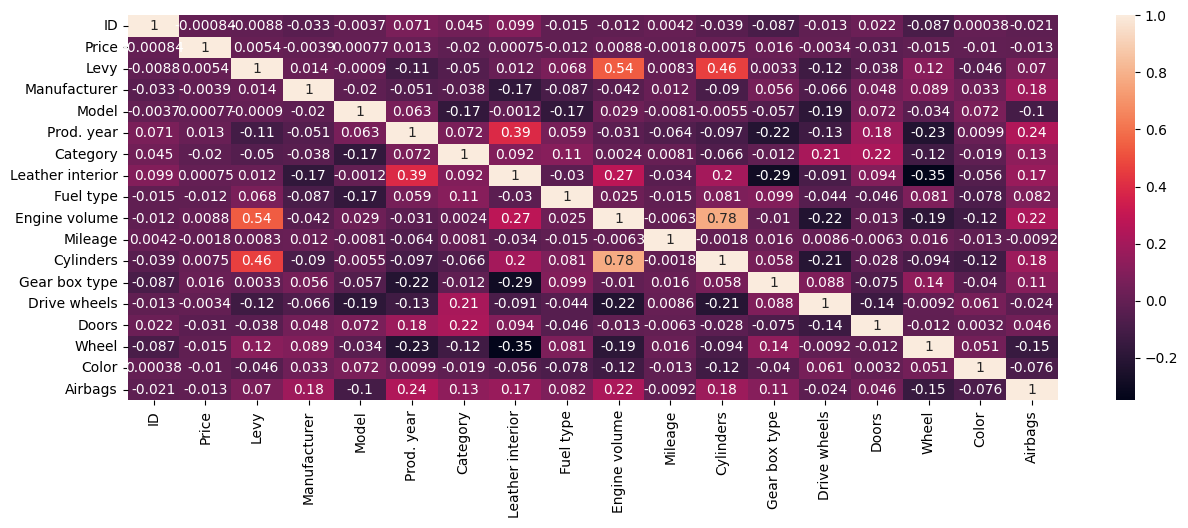

In [35]:
data = df.corr()
plt.figure(figsize=(15,5))
sns.heatmap(data,annot=True)

In [36]:
X = df.drop("Price",axis=1)
y = df["Price"]

In [37]:
Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.3,random_state=42)

In [38]:
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# Xtrain = scaler.fit_transform(Xtrain)
from sklearn.preprocessing import Normalizer

In [39]:
model = LinearRegression()
model.fit(Xtrain,ytrain)

LinearRegression()

In [40]:
ypred = model.predict(Xtest)
ypred

array([ 5085.72075381, 53108.66771539, 11323.30214957, ...,
        6864.42180817,   701.96041269, 12841.51375486])

In [41]:
print("Training Eff: ",model.score(Xtrain,ytrain))
print("Testing Eff: ",model.score(Xtest,ytest))

Training Eff:  0.003098833830215808
Testing Eff:  -0.1533197976155818
